# sCCIgen Benchmark

In [1]:
import numpy as np
import pandas as pd
import os
import glob
import re
from itertools import product
import scanpy as sc
import liana as li

import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
# tight layout by default
plt.rcParams.update({'figure.autolayout': True})

from utils import *

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
from liana.method import cellphonedb, connectome, cellchat, scseqcomm, singlecellsignalr, natmi, logfc, rank_aggregate, geometric_mean
methods = [cellphonedb, connectome, cellchat, scseqcomm, singlecellsignalr, natmi, logfc, rank_aggregate, geometric_mean]

In [3]:
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", message="zero-centering a sparse array")

from anndata import ImplicitModificationWarning
warnings.simplefilter(action='ignore', category=ImplicitModificationWarning)

## Fetch benchmark datasets

In [4]:
directory = "sCCIgen_R1_Benchmark_Data"

count_files = sorted(glob.glob(os.path.join(directory, "*_count_*.tsv")),
                     key=lambda f: int(re.search(r'_([0-9]+)\.tsv$', os.path.basename(f)).group(1)))
expr_pattern_files = sorted(glob.glob(os.path.join(directory, "*_expr_pattern_*.tsv")),
                           key=lambda f: int(re.search(r'_([0-9]+)\.tsv$', os.path.basename(f)).group(1)))
meta_files = sorted(glob.glob(os.path.join(directory, "*_meta_*.tsv")),
                   key=lambda f: int(re.search(r'_([0-9]+)\.tsv$', os.path.basename(f)).group(1)))

## Preprocessing & run LIANA

In [6]:
for i in range(len(count_files)):
    counts_df = pd.read_csv(count_files[i], sep="\t", index_col=0)
    cell_ids = counts_df.columns.tolist()
    adata = sc.AnnData(
        X = counts_df.values.T,
        obs = pd.DataFrame(index = cell_ids)
    )
    spatial = pd.read_csv(meta_files[i], sep = "\t", index_col = 0)
    spatial.index.name = "NAME"
    spatial.rename(columns = {"annotation": "cell_type", "x.loc": "X", "y.loc": "Y"}, inplace = True)
    adata = adata[adata.obs.index.isin(spatial.index)]
    adata.obs = adata.obs.merge(spatial, left_index=True, right_index=True)
    adata.obsm = {}
    adata.obsm['spatial'] = adata.obs[['X', 'Y']].values.astype(np.float32)
    adata.var_names = counts_df.index.astype(str)
    adata.var.index.name = 'gene'
    adata.layers['raw'] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    for method in methods:
        if method.method_name != 'Rank_Aggregate':
                kw = {'supp_columns': ['ligand_pvals', 'receptor_pvals']}
        else:
            kw = {}
        adata.uns[method.method_name] = method(adata,
                                               groupby="cell_type",
                                               use_raw=False,
                                               verbose=False,
                                               n_perms=1000,
                                               n_jobs=10,
                                               inplace=False,
                                               resource_name = "mouseconsensus",
                                               **kw
                                              )
    adata.write_h5ad(f"{directory}/adata/benchmark_adata_{i+1}.h5ad")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
... storing 'cell_type' as cat

## Evaluation

### Custom ground truth

In [7]:
# define custom filter functions
lambdas = {}
lambdas['CellPhoneDB'] = lambda x: x['cellphone_pvals'] < 0.05
lambdas['Connectome'] = lambda x: ((x['ligand_pvals'] < 0.05) & (x['receptor_pvals'] < 0.05) & (x['scaled_weight'] > 0))
lambdas['log2FC'] = lambda x: ((x['ligand_pvals'] < 0.05) & (x['receptor_pvals'] < 0.05) & (x['lr_logfc'] > 0))
# top 5% of ligand-receptor pairs
lambdas['NATMI'] = lambda x: ((x['spec_weight'] > np.quantile(gt['spec_weight'], 0.95))) # NOTE gt
lambdas['SingleCellSignalR'] = lambda x: (x['lrscore'] > 0.6)
lambdas['Rank_Aggregate'] = lambda x: ((x['magnitude_rank'] < 0.05) & (x['specificity_rank'] < 0.05))
lambdas['Geometric Mean'] = lambda x: (x['gmean_pvals'] < 0.05)
lambdas['scSeqComm'] = lambda x: ((x['inter_score'] > 0.95))
lambdas['CellChat'] = lambda x: ((x['cellchat_pvals'] < 0.05) & ((x['ligand_pvals'] < 0.05) | (x['receptor_pvals'] < 0.05)))

In [8]:
custom_gt = pd.read_csv(expr_pattern_files[0], sep='\t')
custom_gt = custom_gt.dropna(subset=["AdjGene"])
custom_gt = custom_gt.rename(columns={"CellType": "source", "AdjCellType": "target", "GeneID": "ligand_x", "AdjGene": "receptor_x"})
custom_gt

,Type,Region,source,ligand_x,target,receptor_x,beta
30,ExprAssoGenes,NaN,Endothelial,Efnb2,ExcitatoryNeuron,Ephb1,0.485518
31,ExprAssoGenes,NaN,ExcitatoryNeuron,Ephb1,Endothelial,Efnb2,0.485518
32,ExprAssoGenes,NaN,Astrocyte,Gas6,ExcitatoryNeuron,Axl,-0.488911
33,ExprAssoGenes,NaN,ExcitatoryNeuron,Axl,Astrocyte,Gas6,-0.488911
34,ExprAssoGenes,NaN,Interneuron,Nptx1,ExcitatoryNeuron,Nptxr,0.479151
35,ExprAssoGenes,NaN,ExcitatoryNeuron,Nptxr,Interneuron,Nptx1,0.479151
36,ExprAssoGenes,NaN,Oligodendrocyte,Nptx1,ExcitatoryNeuron,Nptxr,-0.505699
37,ExprAssoGenes,NaN,ExcitatoryNeuron,Nptxr,Oligodendrocyte,Nptx1,-0.505699
38,ExprAssoGenes,NaN,ExcitatoryNeuron,Nptx1,Interneuron,Nptxr,-0.448803
39,ExprAssoGenes,NaN,Interneuron,Nptxr,ExcitatoryNeuron,Nptx1,-0.448803


In [9]:
def join_pred_truth_custom(lr_res, custom_truth_df):

    lr_res = lr_res.copy()
    
    # Ensure consistent types
    for col in ['ligand_x', 'receptor_x']:
        custom_truth_df[col] = custom_truth_df[col].astype(str)
    for col in ['ligand_complex', 'receptor_complex']:
        lr_res[col] = lr_res[col].astype(str)

    # Create keys for matching
    custom_truth_df['key'] = (
        custom_truth_df['source'] + "|" + 
        custom_truth_df['ligand_x'] + "|" + 
        custom_truth_df['target'] + "|" + 
        custom_truth_df['receptor_x']
    )

    lr_res['key'] = (
        lr_res['source'] + "|" + 
        lr_res['ligand_complex'] + "|" + 
        lr_res['target'] + "|" + 
        lr_res['receptor_complex']
    )
    
    lr_res['truth'] = lr_res['key'].isin(custom_truth_df['key']).astype(int)

    return lr_res

In [10]:
eval_results = pd.DataFrame(columns=['Dataset',
                                     'Method',
                                     'Score',
                                     'AUROC',
                                     "Balanced Accuracy",
                                     'Precision',
                                     "Recall",
                                     "F1",
                                     "F1*",
                                     "F1 (normalised)",
                                     "F1* (normalised)",
                                     "Positive Calls"
                                     ])
scores = li.mt.show_methods()

for i in range(len(count_files)):
    adata = sc.read_h5ad(f"{directory}/adata/benchmark_adata_{i+1}.h5ad")
    
    for method in methods:
        method_name = method.method_name        
        score_keys = scores[scores['Method Name'] == method.method_name]
        lr_res = adata.uns[method_name].copy()

        score_keys = score_keys[['Magnitude Score', 'Specificity Score']].values[0]
        score_keys = [s for s in score_keys if s is not None]

        gt = join_pred_truth_custom(lr_res, custom_gt)
        gt['binary'] = gt.apply(lambdas[method_name], axis=1).astype(int)
        f1 = calc_weighted_f1(gt, score_key='binary', average='binary')
        f1_baseline = generate_random_baseline(gt, score_key='binary',
                                               metric_fun=calc_weighted_f1, 
                                               average='binary')
        f1_norm = (f1/f1_baseline) / 2
        print(f"__{method_name}; f1:{round(f1, 2)}; f1_norm:{round(f1_norm, 2)}")

        acc = calc_accuracy(gt, score_key='binary')

        precision = calc_precision(gt, score_key='binary')
        recall = calc_recall(gt, score_key='binary')
        call_ratio = gt['binary'].sum() / gt.shape[0]

        for score_key in score_keys:
            gt = li.method.process_scores(gt, score_key=score_key)
            auroc = calc_auroc(gt, score_key=score_key, show_plot=False)

            gt['cap'] = (gt[score_key] >= np.quantile(gt[score_key], 0.95)).astype(int)

            f1_cap = calc_weighted_f1(gt, score_key='cap', average='binary')
            f1_baseline = generate_random_baseline(gt, score_key='cap',
                                                   metric_fun=calc_weighted_f1, 
                                                   average='binary')
            f1_cnorm = (f1_cap / f1_baseline) / 2

            eval_results.loc[len(eval_results)] = [f"sccigen_{i+1}", method_name, score_key,
                                                   auroc,
                                                   # odds,  auprc,
                                                   acc, precision, recall,
                                                   f1, f1_cap,
                                                   f1_norm, f1_cnorm,
                                                   call_ratio]

__CellPhoneDB; f1:0.01; f1_norm:0.73
__Connectome; f1:0.03; f1_norm:2.01
__CellChat; f1:0.02; f1_norm:1.11
__scSeqComm; f1:0.02; f1_norm:1.26
__SingleCellSignalR; f1:0.01; f1_norm:0.97
__NATMI; f1:0.05; f1_norm:3.41
__log2FC; f1:0.03; f1_norm:1.93
__Rank_Aggregate; f1:0.02; f1_norm:1.71
__Geometric Mean; f1:0.01; f1_norm:0.82
__CellPhoneDB; f1:0.02; f1_norm:1.11
__Connectome; f1:0.04; f1_norm:2.63
__CellChat; f1:0.03; f1_norm:1.58
__scSeqComm; f1:0.02; f1_norm:1.09
__SingleCellSignalR; f1:0.02; f1_norm:0.93
__NATMI; f1:0.02; f1_norm:1.48
__log2FC; f1:0.04; f1_norm:2.77
__Rank_Aggregate; f1:0.02; f1_norm:1.52
__Geometric Mean; f1:0.02; f1_norm:1.18
__CellPhoneDB; f1:0.02; f1_norm:1.1
__Connectome; f1:0.03; f1_norm:1.91
__CellChat; f1:0.02; f1_norm:1.15
__scSeqComm; f1:0.01; f1_norm:0.94
__SingleCellSignalR; f1:0.02; f1_norm:1.1
__NATMI; f1:0.05; f1_norm:4.18
__log2FC; f1:0.03; f1_norm:1.87
__Rank_Aggregate; f1:0.02; f1_norm:1.77
__Geometric Mean; f1:0.02; f1_norm:1.33
__CellPhoneDB; f1:

In [11]:
eval_results.to_csv(f"{directory}/evals_results_custom_gt.csv")

### Spatial Ground Truth

In [12]:
for i in range(len(count_files)):
    adata = sc.read_h5ad(f"{directory}/adata/benchmark_adata_{i+1}.h5ad")

    li.ut.spatial_neighbors(adata, bandwidth=200, cutoff=0.1, set_diag=True)
    adata_lr = li.mt.bivariate(adata,
                   global_name="morans",
                   use_raw=False, 
                   n_perms=100,
                   nz_prop=0.05,
                   verbose=True,
                   mask_negatives=True,
                   resource_name="mouseconsensus"
                   )
    adata_lr.write_h5ad(f"{directory}/lrdata/benchmark_lrdata_{i+1}.h5ad")

    cpdata = onehot_groupby(adata, groupby='cell_type')
    interactions = list(product(cpdata.var.index, cpdata.var.index))

    adata_ct = li.mt.bivariate(cpdata, 
                   global_name="morans",
                   use_raw=False,
                   nz_prop=0.05,
                   n_perms=100,
                   verbose=True,
                   mask_negatives=True,
                   interactions=interactions,
                   )
    adata_ct.write_h5ad(f"{directory}/cpdata/benchmark_cpdata_{i+1}.h5ad")

Using `.X`!
Converting to sparse csr matrix!
Using resource `mouseconsensus`.
100%|████████████████████████████████████████| 100/100 [00:00<00:00, 674.85it/s]
... storing 'ligand' as categorical
... storing 'receptor' as categorical
Using `.X`!
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/anndata/_core/anndata.py:835: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['Astrocyte', 'Endothelial', 'ExcitatoryNeuron', 'Interneuron', 'Microglia']

    Inferred to be: categorical

Make sure that normalized counts are passed!
Using provided `interactions`.
Removing 6 self-interactions
100%|████████████████████████████████████████| 100/100 [00:00<00:00, 611.10it/s]
... storing 'ligand' as categorical
... storing 'receptor' as categorical
Using `.X`!
Converting to sparse csr matrix!
Using resource `mouseconsensus`.
100%|████████████████████████████████████████| 100/100 [00:00<00:00, 511.80it/s]
... storing 'ligand' as 

In [15]:
eval_results = pd.DataFrame(columns=['Dataset',
                                     'Method',
                                     'Score',
                                     'AUROC',
                                     "Balanced Accuracy",
                                     'Precision',
                                     "Recall",
                                     "F1",
                                     "F1*",
                                     "F1 (normalised)",
                                     "F1* (normalised)",
                                     "Positive Calls"
                                     ])
scores = li.mt.show_methods()

for i in range(len(count_files)):
    adata = sc.read_h5ad(f"{directory}/adata/benchmark_adata_{i+1}.h5ad")
    lrdata = sc.read_h5ad(f"{directory}/lrdata/benchmark_lrdata_{i+1}.h5ad")
    cpdata = sc.read_h5ad(f"{directory}/cpdata/benchmark_cpdata_{i+1}.h5ad")
    
    for method in methods:
        method_name = method.method_name        
        score_keys = scores[scores['Method Name'] == method.method_name]
        lr_res = adata.uns[method_name].copy()

        score_keys = score_keys[['Magnitude Score', 'Specificity Score']].values[0]
        score_keys = [s for s in score_keys if s is not None]

        gt = join_pred_truth(lr_res, lrdata, cpdata)
        gt['binary'] = gt.apply(lambdas[method_name], axis=1).astype(int)
        f1 = calc_weighted_f1(gt, score_key='binary', average='binary')
        f1_baseline = generate_random_baseline(gt, score_key='binary',
                                               metric_fun=calc_weighted_f1, 
                                               average='binary')
        f1_norm = (f1/f1_baseline) / 2
        print(f"__{method_name}; f1:{round(f1, 2)}; f1_norm:{round(f1_norm, 2)}")

        acc = calc_accuracy(gt, score_key='binary')

        precision = calc_precision(gt, score_key='binary')
        recall = calc_recall(gt, score_key='binary')
        call_ratio = gt['binary'].sum() / gt.shape[0]

        for score_key in score_keys:
            gt = li.method.process_scores(gt, score_key=score_key)
            auroc = calc_auroc(gt, score_key=score_key, show_plot=False)

            gt['cap'] = (gt[score_key] >= np.quantile(gt[score_key], 0.95)).astype(int)

            f1_cap = calc_weighted_f1(gt, score_key='cap', average='binary')
            f1_baseline = generate_random_baseline(gt, score_key='cap',
                                                   metric_fun=calc_weighted_f1, 
                                                   average='binary')
            f1_cnorm = (f1_cap / f1_baseline) / 2

            eval_results.loc[len(eval_results)] = [f"sccigen_{i+1}", method_name, score_key,
                                                   auroc,
                                                   # odds,  auprc,
                                                   acc, precision, recall,
                                                   f1, f1_cap,
                                                   f1_norm, f1_cnorm,
                                                   call_ratio]

/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/2695532985.py:35: RuntimeWarning: invalid value encountered in scalar divide
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2776: UserWarning: y_pred contains classes not in y_true
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score

__CellPhoneDB; f1:0.0; f1_norm:nan


/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/2695532985.py:54: RuntimeWarning: invalid value encountered in scalar divide
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/2695532985.py:54: RuntimeWarning: invalid value encountered in scalar divide
/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/2695532985.py:35: RuntimeWarning: invalid value encountered in scalar divide
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2776: UserWarnin

__Connectome; f1:0.0; f1_norm:nan


/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/2695532985.py:54: RuntimeWarning: invalid value encountered in scalar divide
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/2695532985.py:54: RuntimeWarning: invalid value encountered in scalar divide
/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/2695532985.py:35: RuntimeWarning: invalid value encountered in scalar divide
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2776: UserWarnin

...

/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/2695532985.py:54: RuntimeWarning: invalid value encountered in scalar divide
/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/2695532985.py:35: RuntimeWarning: invalid value encountered in scalar divide
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2776: UserWarning: y_pred contains classes not in y_true
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
/Users/shins21/Library/r-miniconda-arm64/envs/lian

__Rank_Aggregate; f1:0.0; f1_norm:nan


/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/2695532985.py:54: RuntimeWarning: invalid value encountered in scalar divide
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/2695532985.py:54: RuntimeWarning: invalid value encountered in scalar divide
/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/2695532985.py:35: RuntimeWarning: invalid value encountered in scalar divide
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2776: UserWarnin

__Geometric Mean; f1:0.0; f1_norm:nan


/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/2695532985.py:54: RuntimeWarning: invalid value encountered in scalar divide
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
/Users/shins21/Library/r-miniconda-arm64/envs/liana-env/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/2695532985.py:54: RuntimeWarning: invalid value encountered in scalar divide


In [16]:
eval_results.to_csv(f"{directory}/evals_results_spatial_gt.csv")

## Plotting

In [17]:
res_custom = pd.read_csv(f"{directory}/evals_results_custom_gt.csv", index_col=0)

# replace expr_prod with Product* when Method is Connectome
res_custom.loc[(res_custom['Score'] == 'expr_prod') & (res_custom['Method'] == 'Connectome'), 'Score'] = 'Product*'
res_custom.loc[(res_custom['Score'] == 'expr_prod') & (res_custom['Method'] == 'NATMI'), 'Score'] = 'Product✳'
res_custom.to_csv(f"{directory}/evals_results_custom_gt_final.csv")

In [18]:
res_custom = pd.read_csv(f"{directory}/evals_results_custom_gt_final.csv", index_col=0)
res_custom['Score'] = res_custom['Score'].str.replace('_', ' ').str.title()

score_order = res_custom.sort_values("Method")['Score'].unique()
res_custom['Score'] = pd.Categorical(res_custom['Score'], categories=score_order, ordered=True)
res_custom['Method'] = pd.Categorical(res_custom['Method'], categories=res_custom['Method'].unique(), ordered=True)

In [19]:
res = pd.read_csv(f"{directory}/evals_results_spatial_gt.csv", index_col=0)

# replace expr_prod with Product* when Method is Connectome
res.loc[(res['Score'] == 'expr_prod') & (res['Method'] == 'Connectome'), 'Score'] = 'Product*'
res.loc[(res['Score'] == 'expr_prod') & (res['Method'] == 'NATMI'), 'Score'] = 'Product✳'
res.to_csv(f"{directory}/evals_results_spatial_gt_final.csv")

In [20]:
res = pd.read_csv(f"{directory}/evals_results_spatial_gt_final.csv", index_col=0)
res['Score'] = res['Score'].str.replace('_', ' ').str.title()

score_order = res.sort_values("Method")['Score'].unique()
res['Score'] = pd.Categorical(res['Score'], categories=score_order, ordered=True)
res['Method'] = pd.Categorical(res['Method'], categories=res['Method'].unique(), ordered=True)

In [21]:
import seaborn as sns
import matplotlib.patches as mpatches

def plot_method_comparison(res, metric, baseline=None, limits=(0,1), x="Score", show_legend=False, figsize=(5, 5), ax=None, ylabel=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    palette = sns.color_palette("Set1", n_colors=res['Method'].nunique())

    method_order = res['Method'].unique()
    numeric_cols = res.select_dtypes(include='number').columns
    order = res.groupby(x)[numeric_cols].median().sort_values(metric, ascending=False).index
    sns.boxplot(x=x, y=metric, data=res, hue='Method', 
                hue_order=method_order, palette=palette, 
                dodge=False, width=0.8, ax=ax, order=order,
                medianprops=dict(color="cyan"))

    if show_legend:
        legend_patches = [mpatches.Patch(color=palette[i], label=method) for i, method in enumerate(method_order)]
        ax.legend(handles=legend_patches, title='Method', loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
    else:
        ax.legend([], [], frameon=False)

    ax.set_ylim(limits)

    ax.set_yticklabels(['{:.2f}'.format(y) for y in ax.get_yticks()])

    if baseline is not None:
        ax.axhline(y=baseline, color='red', linestyle='dashed', linewidth=1)

    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel('', fontsize=14)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    
    magnitude_scores = ['Lr Means',
                        'Product*',
                        'Lr Probs',
                        'Inter Score',
                        'Lrscore',
                        'Product✳',
                        'Magnitude Rank',
                        'Lr Gmeans',
                        ]
    
    for label in ax.get_xticklabels():
        if label.get_text() in magnitude_scores:
            label.set_color('darkred')
        else:
            label.set_color('black')
    
    if ax is None:
        plt.tight_layout()
        plt.show()

/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/1748361497.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/1748361497.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/1748361497.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/1748361497.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/var/folders/cs/15_p8wfn7lsbsk6qbrwyckqw0000gp/T/ipykernel_31492/1748361497.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of 

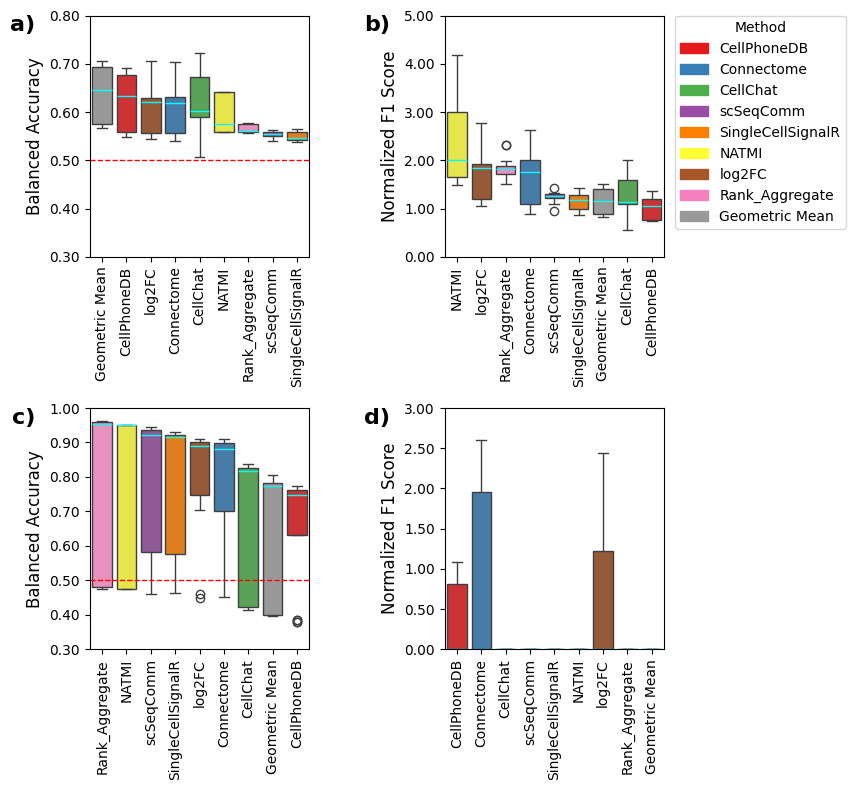

In [22]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(10.75, 8))

gs = gridspec.GridSpec(2, 2)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

plot_method_comparison(res_custom, metric='Balanced Accuracy', x="Method", limits=(0.3, 0.8), figsize=(5, 5), baseline=0.5, ax=ax0, ylabel="Balanced Accuracy")
plot_method_comparison(res_custom, metric='F1 (normalised)', x="Method", figsize=(5, 5), ax=ax1, show_legend=True, limits=(0, 5), ylabel="Normalized F1 Score")
plot_method_comparison(res, metric='Balanced Accuracy', x="Method", limits=(0.3, 1), figsize=(5, 5), baseline=0.5, ax=ax2, ylabel="Balanced Accuracy")
plot_method_comparison(res, metric='F1 (normalised)', x="Method", figsize=(5, 5), ax=ax3, limits=(0, 3), ylabel="Normalized F1 Score")


labs = ['a)', 'b)', 'c)', 'd)']
for i, ax in enumerate([ax0,ax1, ax2, ax3]):
    ax.text(-0.25, 1.00, labs[i], transform=ax.transAxes, fontsize=16, va='top', ha='right', fontweight='bold')

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig("benchmark_figure.pdf")
plt.show()